In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fftpack
from scipy.linalg import toeplitz
from scipy.signal import lfilter # 需要导入 lfilter 来进行 AR 滤波

In [26]:
class BearingAnalyzer:
    def __init__(self, fs=25600, xlim=100):
        """
        初始化分析器
        :param fs: 采样频率
        :param xlim: 频谱图显示的频率上限
        """
        self.fs = fs
        self.xlim = xlim
    def ar_prewhiten_demo(self, y, order=30):
        """简单的 AR 预白化实现（已针对长数据进行极速优化）"""
        # 1. 极速计算自相关：只计算前 order+1 个延迟点，避开 mode='full' 的计算黑洞
        r = np.zeros(order + 1)
        for k in range(order + 1):
            if k == 0:
                r[k] = np.dot(y, y)
            else:
                r[k] = np.dot(y[:-k], y[k:])
                
        # 2. 求解 Yule-Walker 方程 (Toeplitz 矩阵)
        try:
            R = toeplitz(r[:-1])
            R += np.eye(order) * 1e-9 # 正则化防止奇异
            a = np.linalg.solve(R, -r[1:])
            
            A = np.concatenate(([1.0], a))
            
            # 【关键修复1】预白化求残差是FIR滤波，AR系数 A 应当作为分子
            y_white = lfilter(A, [1.0], y)
            
            # 【关键修复2】print 必须写在 return 之前才能被执行
            print('预白化成功')
            return y_white  
            
        except Exception as e:
            # 捕获异常并打印具体原因，方便排错
            print(f'预白化失败，原因: {e}。返回原信号')
            return y

    def get_envelope(self, data, max_points=640000):
        """核心算法：提取包络谱"""
        # 截取信号并去直流
        xt = data[:max_points]
        xt = xt-np.mean(xt)
        ht = fftpack.hilbert(xt)
        at = np.sqrt(xt ** 2 + ht ** 2)
        at = at - np.mean(at)

        # FFT 变换
        n = len(at)
        am = np.abs(np.fft.fft(at))
        am = (am / n) * 2

        # 取正频率部分
        half_n = n // 2
        freq = np.fft.fftfreq(n, d=1 / self.fs)[:half_n]
        amp = am[:half_n]
        return freq, amp

    def plot_diagnostic(self, ax, freq, amp, motor_f, title, fault_type='BSF'):
        """绘图与理论频率标注"""
        # 绘制包络谱
        ax.plot(freq, amp, color='#1f77b4', lw=1.2, label='Envelope', zorder=3)
        ax.fill_between(freq, amp, color='#1f77b4', alpha=0.15)
        # 细节优化
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlim(0, self.xlim)
        # 自动调整Y轴刻度 (避开1Hz以内的低频干扰)
        valid_idx = freq > 1
        if any(valid_idx):
            ax.set_ylim(0, np.max(amp[valid_idx]) * 1.5)
        ax.legend(loc='upper right', fontsize=8)

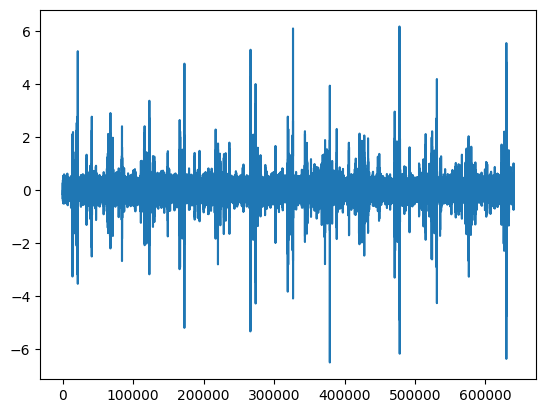

In [27]:
df=pd.read_csv('../数据集/BJTU/滚动体/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv',usecols=['CH17'])
data = df.iloc[:, 0].values
x=df.index.values

plt.plot(x,data)

In [28]:
analyzer = BearingAnalyzer(fs=25600, xlim=100)
data=analyzer.ar_prewhiten_demo(data,order=30)

预白化成功


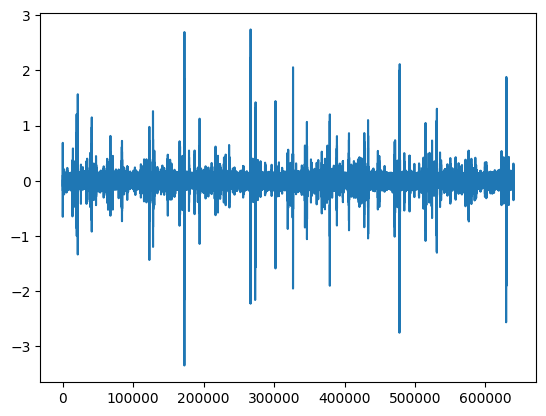

In [29]:
plt.plot(data)

In [30]:
freq, amp=analyzer.get_envelope(data, max_points=640000)

(0.0, 100.0)

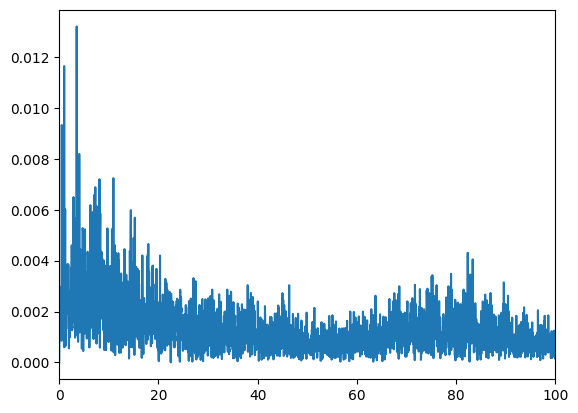

In [31]:
plt.plot(freq,amp)
plt.xlim(0,100)

预白化及其耗费时间